# Credit Prediction Analysis

## Introduction

In [1]:
#Load the librarys
import pandas as pd #To work with dataset
import numpy as np #Math library
import seaborn as sns #Graph library that use matplot in background
import matplotlib.pyplot as plt #to plot some parameters in seaborn

df_credit = pd.read_csv('/Users/JumpMan/Downloads/Feb 2025 Project/Credit risk analysis/german_credit_data.csv.xls', index_col = 0)

## Reviewing and Cleaning The Data 

In [11]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 78.1+ KB


In [10]:
# Looking at unique vales 
df_credit.nunique()

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
dtype: int64

In [12]:
#Looking at the data
df_credit.head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,NaN,NaN,9055,36,education
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


In [13]:
print("Saving accounts unique values:\n", df_credit["Saving accounts"].unique())
print("\nChecking account unique values:\n", df_credit["Checking account"].unique())

Saving accounts unique values:
 [nan 'little' 'quite rich' 'rich' 'moderate']

Checking account unique values:
 ['little' 'moderate' nan 'rich']


In [14]:
print("Saving accounts responses:\n", df_credit["Saving accounts"])
print("\nChecking account responses:\n", df_credit["Checking account"])


Saving accounts responses:
 0           NaN
1        little
2        little
3        little
4        little
         ...   
995      little
996      little
997      little
998      little
999    moderate
Name: Saving accounts, Length: 1000, dtype: object

Checking account responses:
 0        little
1      moderate
2           NaN
3        little
4        little
         ...   
995         NaN
996      little
997         NaN
998      little
999    moderate
Name: Checking account, Length: 1000, dtype: object


In [15]:
# Replacing nan with none
df_credit["Saving accounts"].fillna("none", inplace=True)
df_credit["Checking account"].fillna("none", inplace=True)


In [16]:
print("Saving accounts unique values:\n", df_credit["Saving accounts"].unique())
print("\nChecking account unique values:\n", df_credit["Checking account"].unique())

Saving accounts unique values:
 ['none' 'little' 'quite rich' 'rich' 'moderate']

Checking account unique values:
 ['little' 'moderate' 'none' 'rich']


In [17]:
#Looking at the updated data
df_credit.head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,none,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,none,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
5,35,male,1,free,none,none,9055,36,education
6,53,male,2,own,quite rich,none,2835,24,furniture/equipment
7,35,male,3,rent,little,moderate,6948,36,car
8,61,male,1,own,rich,none,3059,12,radio/TV
9,28,male,3,own,little,moderate,5234,30,car


## Data Exploration and Visualization

In [19]:
print(df_credit.isnull().sum())

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [20]:
#Summarizing the statistics
df_credit.describe(include="all")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,1000.000000,1000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,2,NaN,3,5,4,NaN,NaN,8
top,NaN,male,NaN,own,little,none,NaN,NaN,car
freq,NaN,690,NaN,713,603,394,NaN,NaN,337
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN


__Distribution of numerical features__

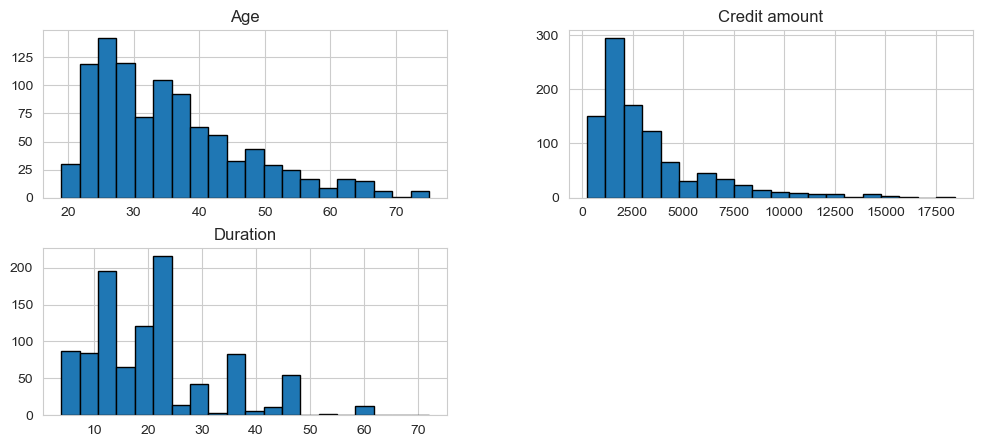

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Histogram for numerical features
df_credit[['Age', 'Credit amount', 'Duration']].hist(figsize=(12, 5), bins=20, edgecolor="black")
plt.show()


__Distribution of categorical features__

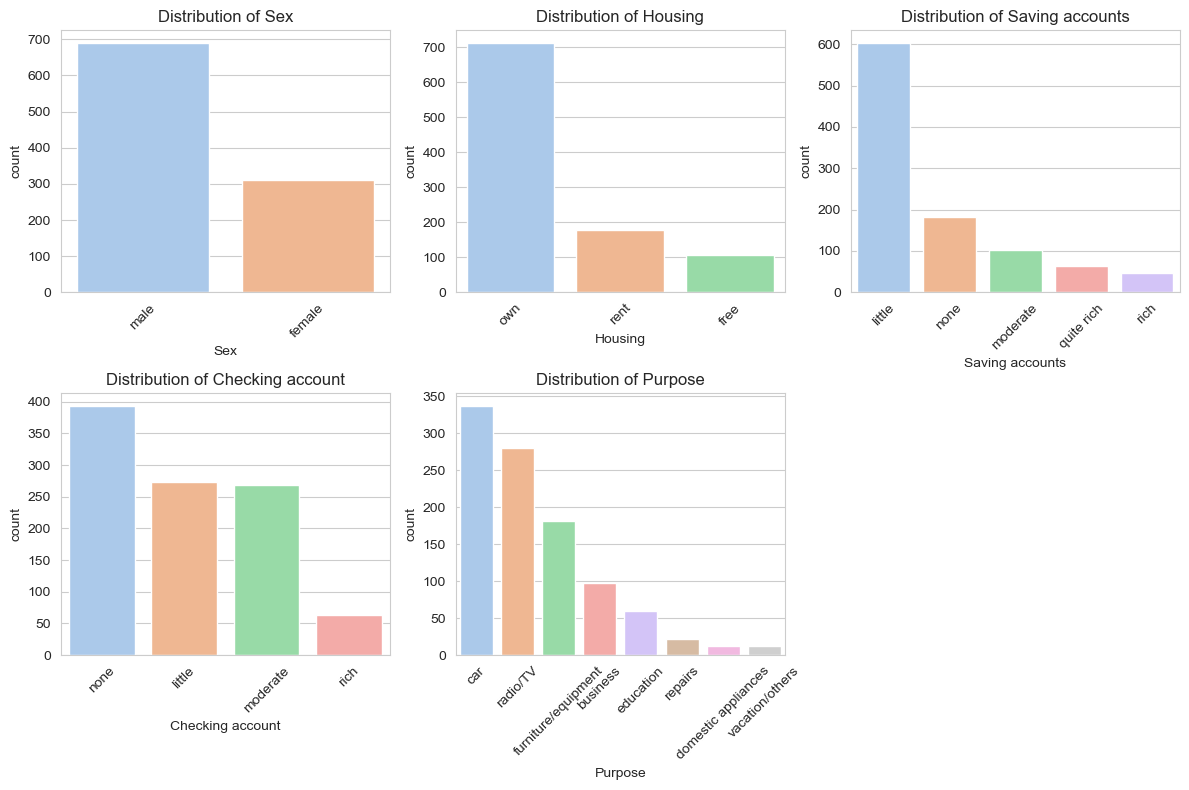

In [23]:
# Count plots for categorical variables
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df_credit[col], palette="pastel", order=df_credit[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

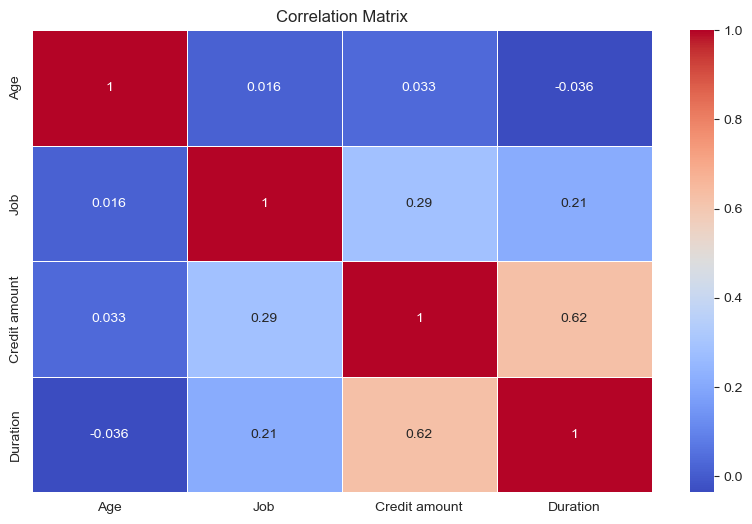

In [25]:
#Correlation analysis
# Select only numerical columns
numeric_df = df_credit.select_dtypes(include=["number"])

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


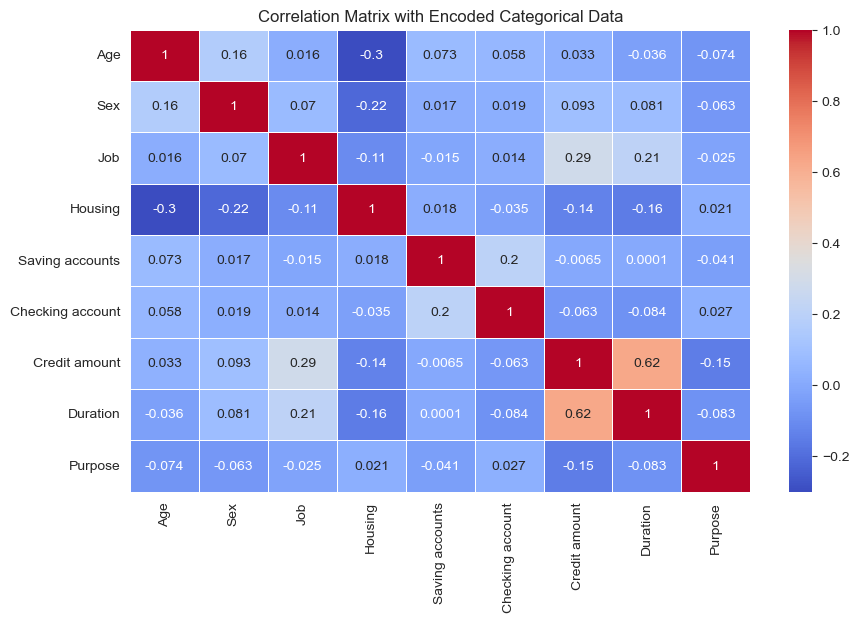

In [26]:
#Encode Categorical Variables First
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
categorical_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
df_encoded = df_credit.copy()

for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Compute correlation with encoded categorical data
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix with Encoded Categorical Data")
plt.show()


__Credit Amount vs Duration Analysis__


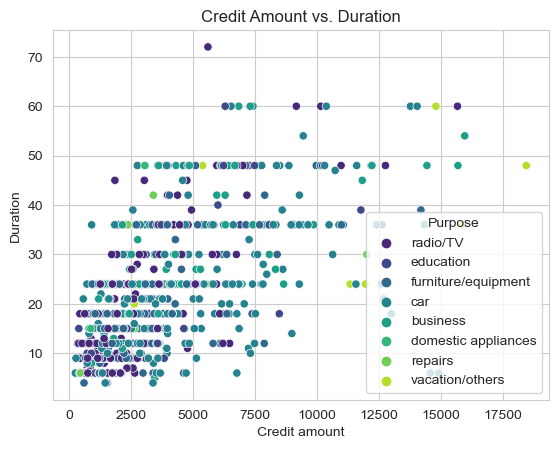

In [27]:
sns.scatterplot(data=df_credit, x="Credit amount", y="Duration", hue="Purpose", palette="viridis")
plt.title("Credit Amount vs. Duration")
plt.show()

__Credit amount by Housing type__

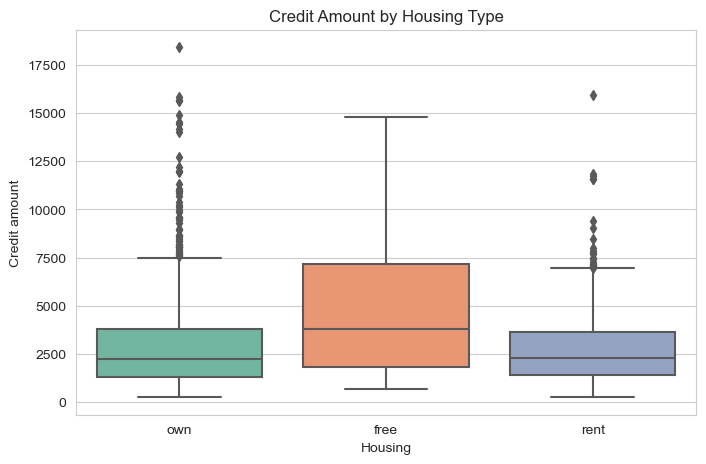

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_credit, x="Housing", y="Credit amount", palette="Set2")
plt.title("Credit Amount by Housing Type")
plt.show()


__Distribution of Credit Amount Across Different Purposes__


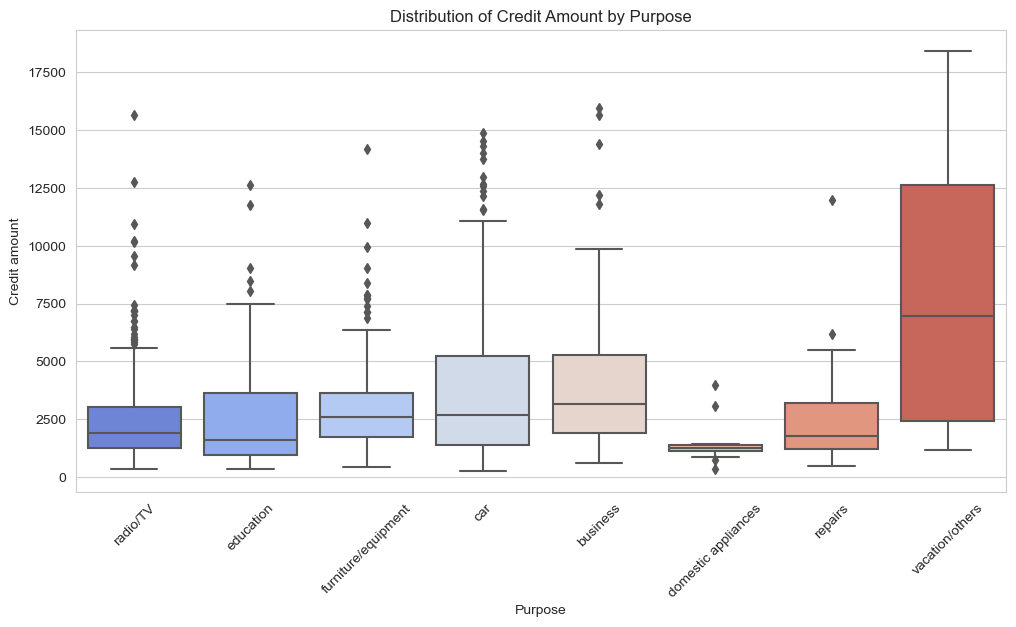

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_credit, x="Purpose", y="Credit amount", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Distribution of Credit Amount by Purpose")
plt.show()


__Relationship Between Age and Credit Amount__

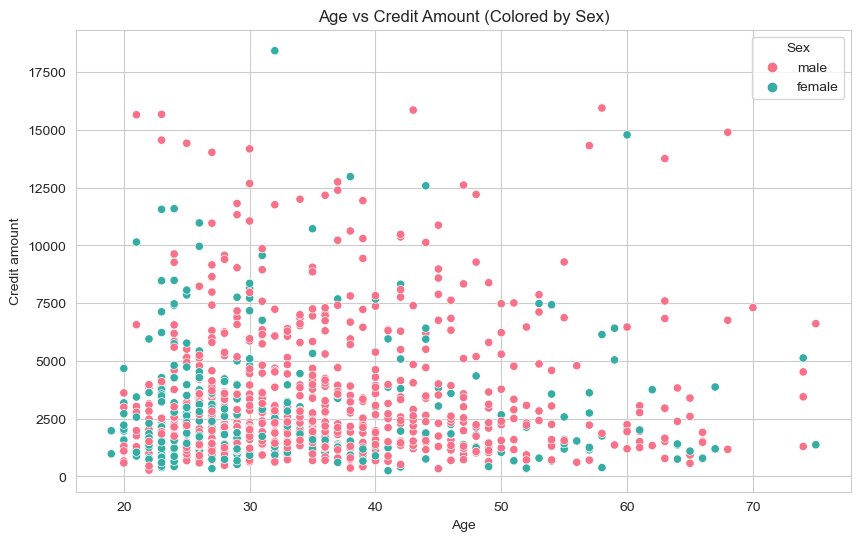

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_credit, x="Age", y="Credit amount", hue="Sex", palette="husl")
plt.title("Age vs Credit Amount (Colored by Sex)")
plt.show()

__Loan Duration Distribution Based on Housing Type__


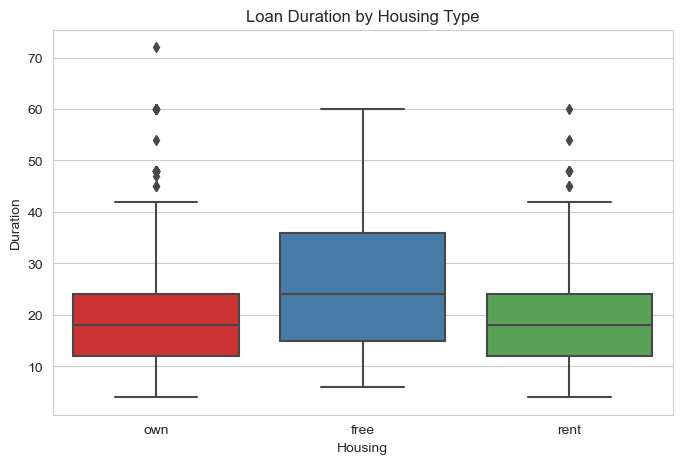

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_credit, x="Housing", y="Duration", palette="Set1")
plt.title("Loan Duration by Housing Type")
plt.show()

__Job Level vs. Credit Amount__

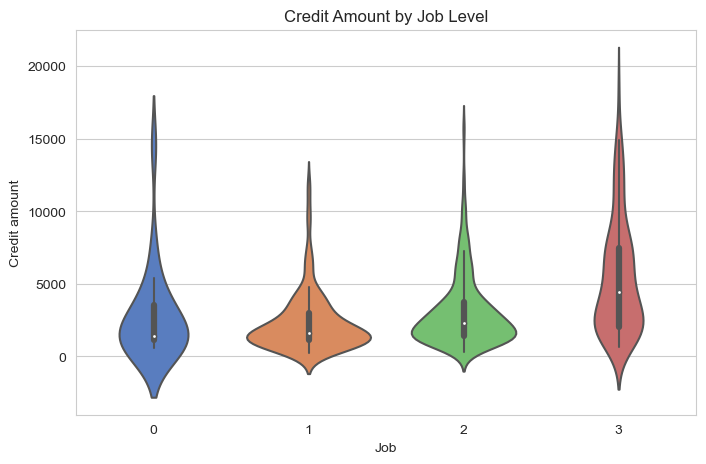

In [32]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_credit, x="Job", y="Credit amount", palette="muted")
plt.title("Credit Amount by Job Level")
plt.show()

__Count of Loan Purposes by Gender__

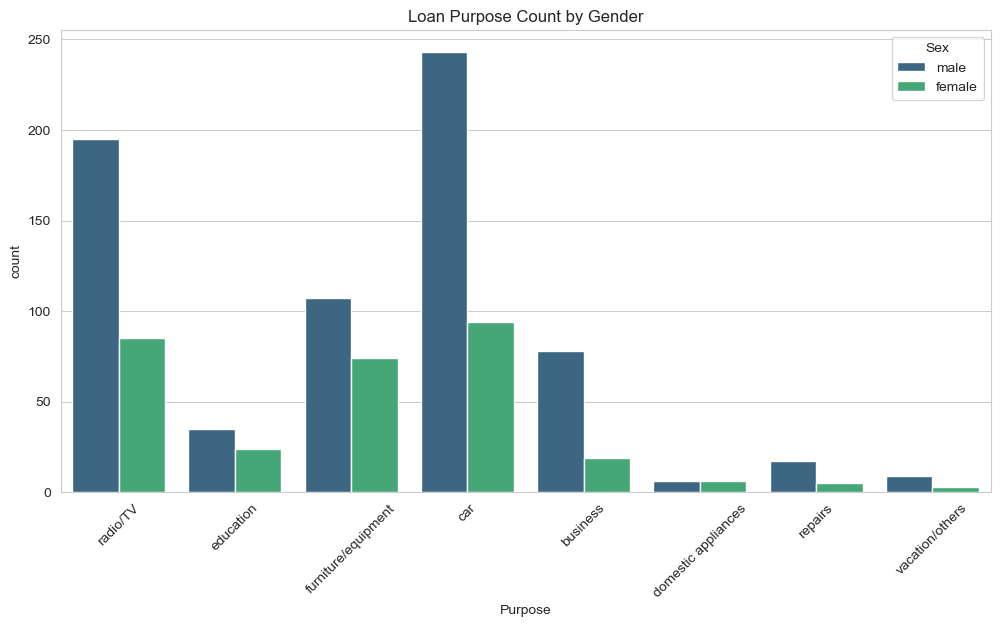

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_credit, x="Purpose", hue="Sex", palette="viridis")
plt.xticks(rotation=45)
plt.title("Loan Purpose Count by Gender")
plt.show()

__Credit Amount vs Savings Account Status__

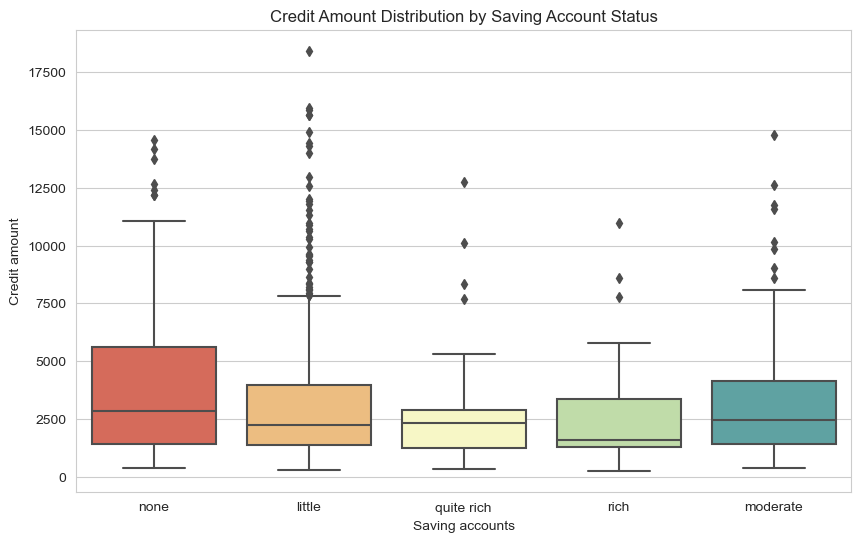

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_credit, x="Saving accounts", y="Credit amount", palette="Spectral")
plt.title("Credit Amount Distribution by Saving Account Status")
plt.show()

__Distribution of Credit Amount by Checking Account Status__

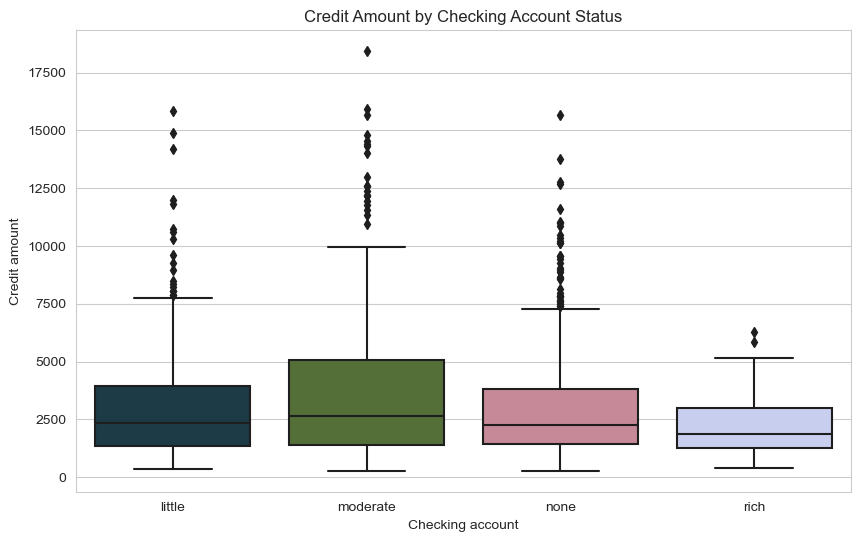

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_credit, x="Checking account", y="Credit amount", palette="cubehelix")
plt.title("Credit Amount by Checking Account Status")
plt.show()


__Age Distribution by Housing Type__

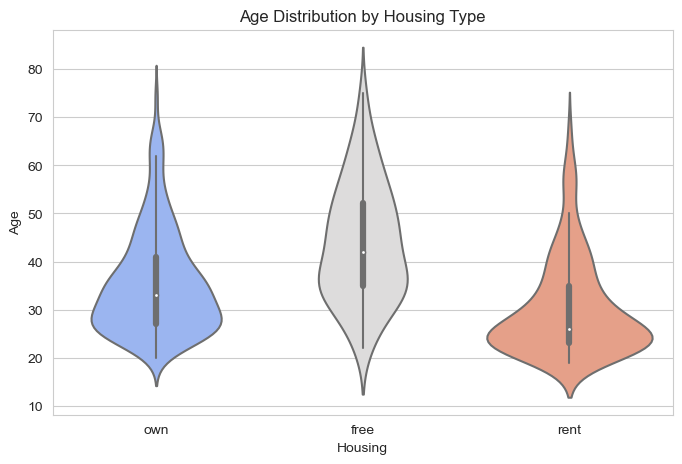

In [36]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_credit, x="Housing", y="Age", palette="coolwarm")
plt.title("Age Distribution by Housing Type")
plt.show()

__Loan Duration by Savings Account__

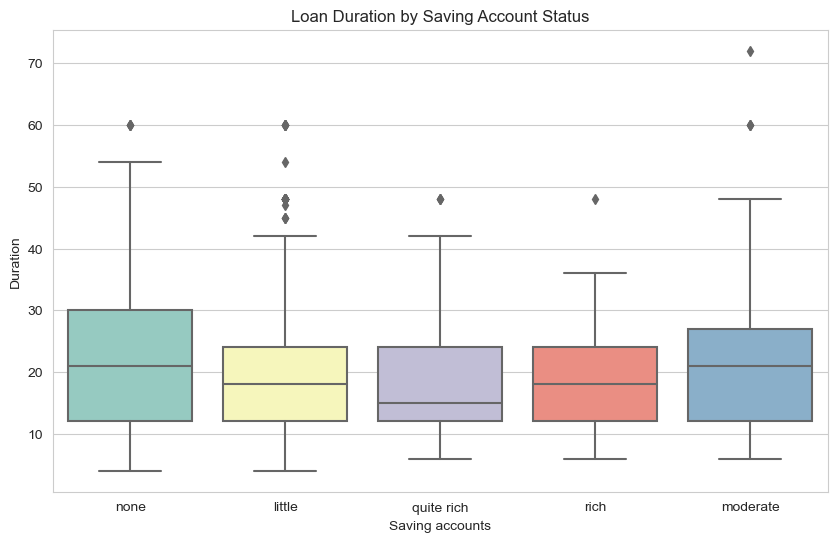

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_credit, x="Saving accounts", y="Duration", palette="Set3")
plt.title("Loan Duration by Saving Account Status")
plt.show()

### Good vs Bad Credit Visualization

__Creating new column for credit category__

In [38]:
# Define a simple rule for Good vs. Bad credit (you can refine it)
df_credit["Credit Status"] = df_credit.apply(lambda row: "Good Credit" if row["Credit amount"] <= 3000 and row["Duration"] <= 12 else "Bad Credit", axis=1)

__Pie Chart for Good vs Bad Credit__

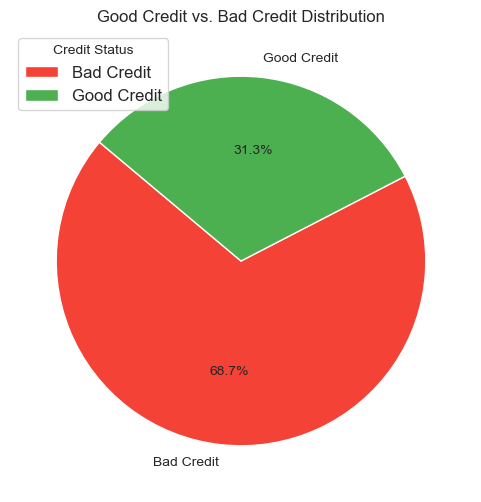

In [48]:
import matplotlib.pyplot as plt

# Count occurrences of each credit category
credit_counts = df_credit["Credit Status"].value_counts()

# Ensure "Good Credit" is green and "Bad Credit" is red
credit_status_colors = ["#4CAF50" if status == "Good Credit" else "#F44336" for status in credit_counts.index]

# Plot Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    credit_counts, 
    labels=credit_counts.index, 
    autopct='%1.1f%%', 
    colors=credit_status_colors, 
    startangle=140
)

# Add legend
plt.legend(
    labels=credit_counts.index, 
    loc="upper left", 
    title="Credit Status", 
    fontsize=12
)

plt.title("Good Credit vs. Bad Credit Distribution")
plt.show()


__Pie Chart for Good vs. Bad Credit by Housing Type__

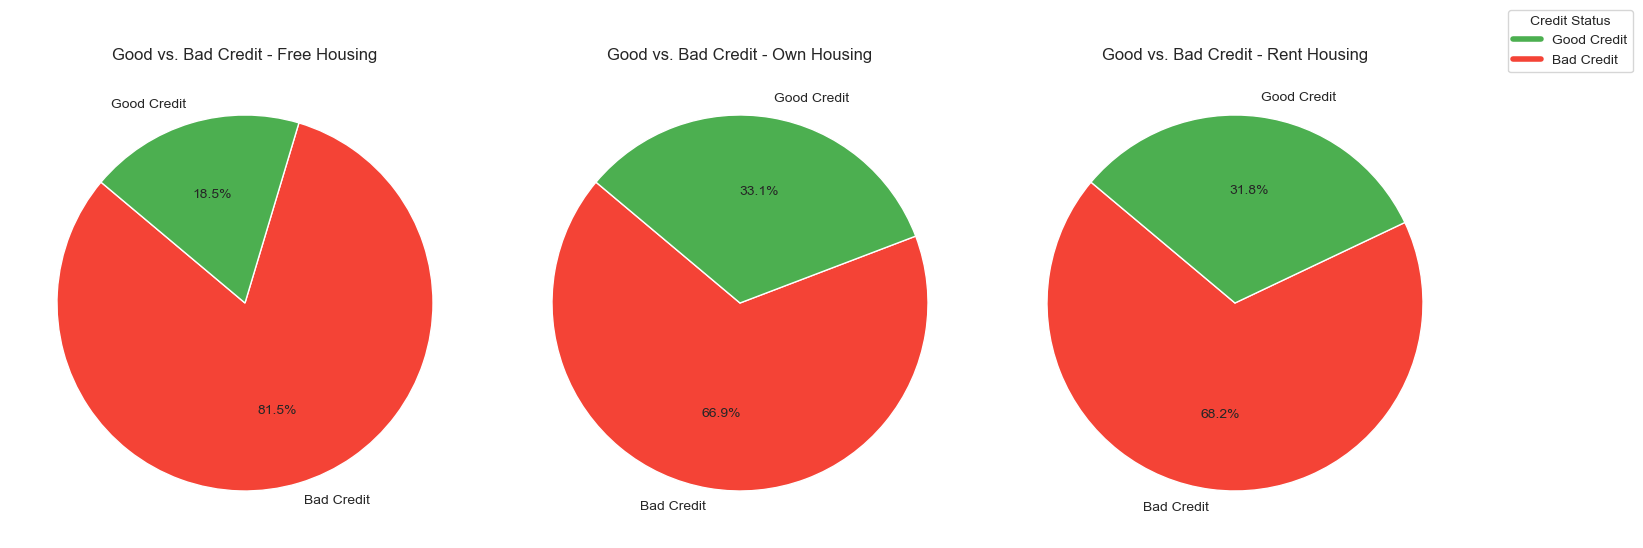

In [45]:
import matplotlib.pyplot as plt

# Group data by Housing and Credit Status
housing_credit_counts = df_credit.groupby("Housing")["Credit Status"].value_counts().unstack()

# Define colors for Good and Bad Credit
colors = {"Good Credit": "#4CAF50", "Bad Credit": "#F44336"}

# Create subplots
fig, axes = plt.subplots(1, len(housing_credit_counts), figsize=(15, 5))

# Get unique housing types
housing_types = housing_credit_counts.index

# Plot pie charts for each Housing type
for i, housing in enumerate(housing_types):
    wedges, texts, autotexts = axes[i].pie(
        housing_credit_counts.loc[housing], 
        labels=housing_credit_counts.columns, 
        autopct='%1.1f%%', 
        colors=[colors[label] for label in housing_credit_counts.columns], 
        startangle=140
    )
    
    axes[i].set_title(f"Good vs. Bad Credit - {housing.capitalize()} Housing")

# Add a common legend outside the subplots
handles = [plt.Line2D([0], [0], color=colors[label], lw=4) for label in colors]
fig.legend(handles, colors.keys(), loc="upper right", bbox_to_anchor=(1.1, 1.1), title="Credit Status")

plt.tight_layout()
plt.show()


__Pie Chart for Good vs Bad Credit by Job Level__

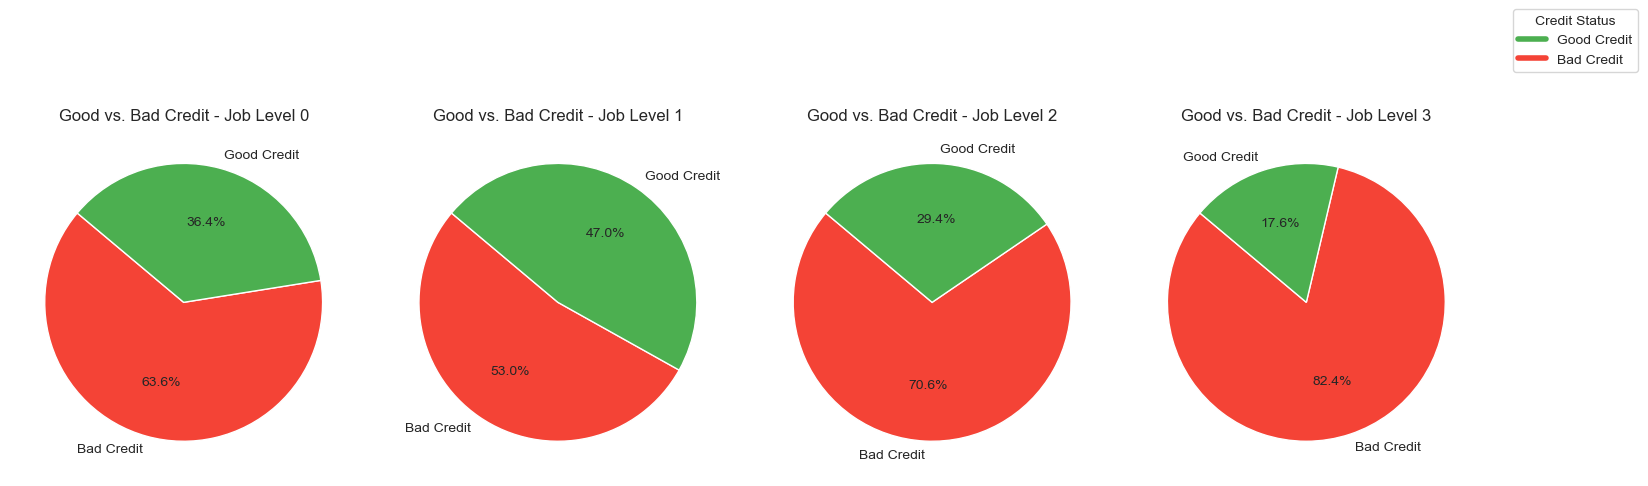

In [46]:
import matplotlib.pyplot as plt

# Group data by Job level and Credit Status
job_credit_counts = df_credit.groupby("Job")["Credit Status"].value_counts().unstack()

# Define colors for Good and Bad Credit
colors = {"Good Credit": "#4CAF50", "Bad Credit": "#F44336"}

# Plot pie charts for each Job level
fig, axes = plt.subplots(1, len(job_credit_counts), figsize=(15, 5))

# Loop through each job level and plot pie chart
for i, job in enumerate(job_credit_counts.index):
    wedges, texts, autotexts = axes[i].pie(
        job_credit_counts.loc[job], 
        labels=job_credit_counts.columns, 
        autopct='%1.1f%%', 
        colors=[colors[label] for label in job_credit_counts.columns], 
        startangle=140
    )
    
    axes[i].set_title(f"Good vs. Bad Credit - Job Level {job}")

# Add a common legend outside the subplots
handles = [plt.Line2D([0], [0], color=colors[label], lw=4) for label in colors]
fig.legend(handles, colors.keys(), loc="upper right", bbox_to_anchor=(1.1, 1.1), title="Credit Status")

plt.tight_layout()
plt.show()


# Machine Learning

Accuracy Score:  0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       128
           1       0.99      0.96      0.97        72

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



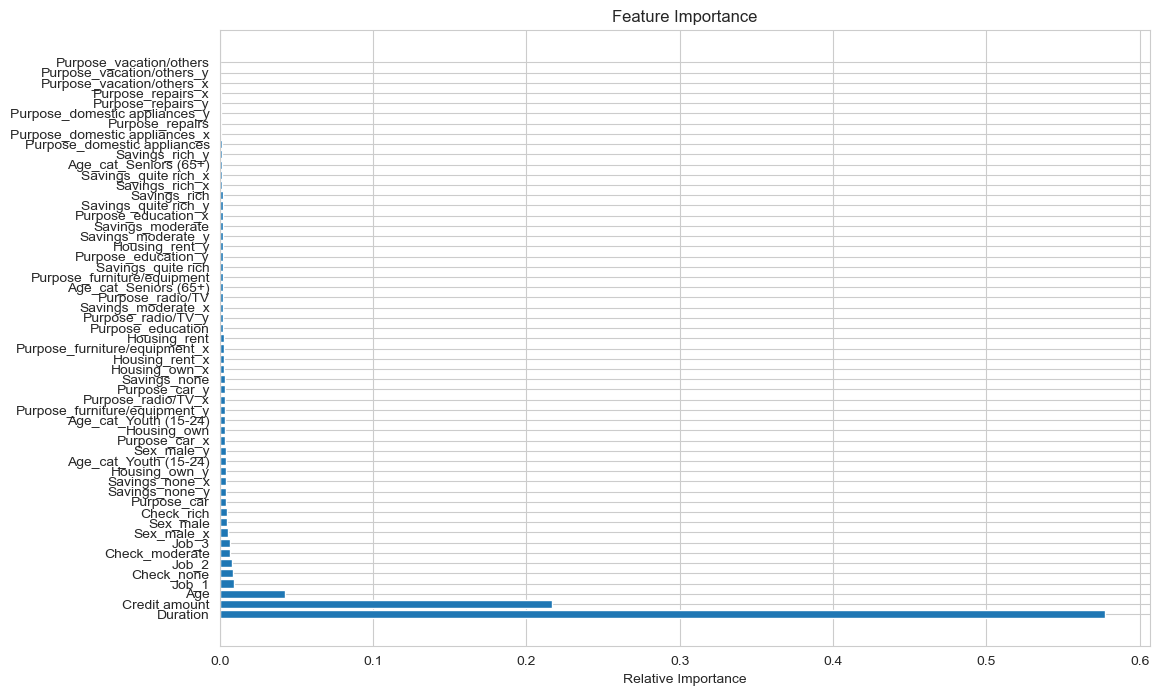

In [80]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df_credit, columns=["Job", "Age_cat"], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop(columns=["Credit Status", "Credit Status_Good Credit", "Credit Status_Bad Credit"])
y = df_encoded["Credit Status"]

# Convert 'Credit Status' to numeric (Good Credit = 1, Bad Credit = 0)
y = y.map({"Good Credit": 1, "Bad Credit": 0})

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot feature importance
features = X.columns
importances = clf.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance")
plt.barh(range(X.shape[1]), importances[indices], align="center")
plt.yticks(range(X.shape[1]), features[indices])
plt.xlabel("Relative Importance")
plt.show()


# Machine Learning Analysis: Credit Status Prediction

### Overview

In this project, we used a **Random Forest Classifier** to predict the credit status (either "Good Credit" or "Bad Credit") of individuals based on various features. The dataset includes various demographic and financial attributes such as job, age category, checking account status, and savings type, among others. We used a **supervised learning approach** for this binary classification problem.

### Key Steps and Ideas Behind the Code

1. **Data Preprocessing**:
   - **One-Hot Encoding**: 
     The categorical variables, such as "Job" and "Age category," were encoded using **one-hot encoding**. This transforms categorical features into a format that can be directly used by the machine learning algorithm (i.e., by converting them into binary columns).
     - `drop_first=True`: This ensures that the first category of each categorical variable is dropped to avoid multicollinearity, as one column can fully represent the others.
   - **Feature and Target Selection**:
     - Features (`X`): All columns, excluding the target variable "Credit Status" and its one-hot encoded variants ("Good Credit" and "Bad Credit").
     - Target (`y`): The "Credit Status" column, which was transformed into numeric values ("Good Credit" = 1, "Bad Credit" = 0) for the classifier.
   - **Train-Test Split**: 
     The data was split into a training set (80%) and a testing set (20%) using `train_test_split`. This helps evaluate the model's performance on unseen data.

2. **Model Training**:
   - A **Random Forest Classifier** was used for training the model. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. It is particularly useful for handling overfitting and ensuring robust predictions.
     - `n_estimators=100`: Specifies the number of trees in the forest. The larger the number of trees, the more robust the model generally becomes.
     - `random_state=42`: Ensures reproducibility of the results by setting the random seed.

3. **Model Evaluation**:
   - **Accuracy**: 
     The overall accuracy of the model is computed, which represents the proportion of correctly classified instances out of all instances. In this case, the accuracy is **98%**, indicating that the model performs exceptionally well.
   
   - **Classification Report**:
     The classification report provides several key metrics, including precision, recall, and F1-score:
     - **Precision**: The proportion of positive predictions that were actually correct. For "Good Credit", precision is 0.99, meaning 99% of instances predicted as "Good Credit" were actually "Good Credit".
     - **Recall**: The proportion of actual positives that were correctly identified. For "Bad Credit", recall is 0.99, indicating the model correctly identified 99% of "Bad Credit" instances.
     - **F1-score**: The harmonic mean of precision and recall. An F1-score closer to 1 indicates a better balance between precision and recall. The model's F1-scores are 0.98 and 0.97 for "Bad Credit" and "Good Credit" respectively, suggesting a well-balanced model.

   - **Macro Average**: 
     This metric averages the precision, recall, and F1-score across both classes (Good Credit and Bad Credit), treating them equally. The model's macro average scores are all 0.98, which reinforces its overall excellent performance.

   - **Weighted Average**: 
     This averages the precision, recall, and F1-score weighted by the number of instances in each class. The weighted averages are similar to the macro averages, reflecting that the model performs well across both classes, irrespective of their frequencies.

4. **Feature Importance**:
   - Random Forest allows us to measure the **importance** of each feature in making predictions. Features with higher importance contribute more significantly to the final decision made by the model.
   - The plot of feature importance shows the relative importance of different features used in the model, allowing us to understand which variables play the most crucial roles in predicting the credit status.

### Insights from the Results

- **High Accuracy (98%)**: The model is highly accurate, with very few misclassifications. This suggests that the features in the dataset provide strong predictive power for the credit status.
- **Balanced Model**: 
  - The **precision** and **recall** values for both classes are very high, which indicates that the model is effective at distinguishing between "Good Credit" and "Bad Credit" without significant bias toward either class.
  - The **F1-scores** are balanced and close to 1, implying that the model performs well in both identifying "Good Credit" and "Bad Credit" instances without favoring one.
- **Feature Importance**:
  - The **feature importance plot** helps to identify which attributes, such as "Purpose of Credit" and "Housing Status", have the most significant influence on predicting whether a person will have good or bad credit. This can offer valuable insights for domain experts, as certain features may be more impactful than others.

### Conclusion

The model's high accuracy, coupled with excellent precision, recall, and F1-scores, suggests that the **Random Forest Classifier** is well-suited for predicting credit status based on the given features. The feature importance analysis also provides valuable insights into which factors are most predictive of an individual's creditworthiness. This analysis could be further improved by tuning hyperparameters, using additional features, or applying more advanced models.

The results indicate a strong foundation for deploying this model in a real-world setting, such as in credit scoring systems, where accurately classifying creditworthiness is critical.
